In [1]:
from resources.helper.helper_dataset import get_dataloaders_mnist
from resources.helper.helper_evaluation import set_all_seeds, set_deterministic
from resources.helper.helper_train import train_model,train_autoencoder
from resources.helper.helper_plotting import plot_training_loss, plot_accuracy, show_examples, plot_latent_space_with_labels, plot_generated_images

import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [3]:
train_loader, valid_loader, test_loader = get_dataloaders_mnist(
    batch_size=256, 
    num_workers=2, 
    validation_fraction=0)

In [ ]:
class Reshape(torch.nn.Module):
    def __init__(self, *args):
        super().__init__()
        self.shape = args

    def forward(self, x):
        return x.view(self.shape)

#in video tuttorial
# class Trim(torch.nn.Module):
#     def __init__(self, *args):
#         super().__init__()

    def forward(self, x):
        return x[:, :, :28, :28]


class AutoEncoder(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = torch.nn.Sequential( 
                torch.nn.Conv2d(1, 32, stride=(1, 1), kernel_size=(3, 3), padding=1),
                torch.nn.LeakyReLU(0.01),
                torch.nn.Conv2d(32, 64, stride=(2, 2), kernel_size=(3, 3), padding=1),
                torch.nn.LeakyReLU(0.01),
                torch.nn.Conv2d(64, 64, stride=(2, 2), kernel_size=(3, 3), padding=1),
                torch.nn.LeakyReLU(0.01),
                torch.nn.Conv2d(64, 64, stride=(1, 1), kernel_size=(3, 3), padding=1),
                torch.nn.Flatten(),
                torch.nn.Linear(3136, 2) # here the size of image reduces to 7x7 after applying filter
        )
        #in video tutorial
        # self.decoder = torch.nn.Sequential(
        #         torch.nn.Linear(2, 3136),
        #         Reshape(-1, 64, 7, 7),
        #         torch.nn.ConvTranspose2d(64, 64, stride=(1, 1), kernel_size=(3, 3), padding=1),
        #         torch.nn.LeakyReLU(0.01),
        #         torch.nn.ConvTranspose2d(64, 64, stride=(2, 2), kernel_size=(3, 3), padding=1),                
        #         torch.nn.LeakyReLU(0.01),
        #         torch.nn.ConvTranspose2d(64, 32, stride=(2, 2), kernel_size=(3, 3), padding=0),                
        #         torch.nn.LeakyReLU(0.01),
        #         torch.nn.ConvTranspose2d(32, 1, stride=(1, 1), kernel_size=(3, 3), padding=0), 
        #         Trim(),  # 1x29x29 -> 1x28x28
        #         torch.nn.Sigmoid()
        #         )

         # new code
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(2, 3136),
            torch.nn.LeakyReLU(0.01),
            torch.nn.Unflatten(1,(64,7,7)),
            torch.nn.ConvTranspose2d(64, 64, stride=(1, 1), kernel_size=(3, 3), padding=1),
            torch.nn.LeakyReLU(0.01),
            torch.nn.ConvTranspose2d(64, 64, stride=(2, 2), kernel_size=(3, 3), padding=1,output_padding=1),                
            torch.nn.LeakyReLU(0.01),
            torch.nn.ConvTranspose2d(64, 32, stride=(2, 2), kernel_size=(3, 3), padding=1,output_padding=1),                
            torch.nn.LeakyReLU(0.01),
            torch.nn.ConvTranspose2d(32, 1, stride=(1, 1), kernel_size=(3, 3), padding=1), 
            torch.nn.Sigmoid()
            )

       


    def forward(self, x):
        x = self.encoder(x)
        # print("1: ",x.shape)
        x = self.decoder(x)
        # print("2: ",x.shape)

        return x

In [35]:
set_all_seeds(42)

model = AutoEncoder()
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  

In [36]:
log_dict = train_autoencoder(num_epochs=5, model=model, 
                                optimizer=optimizer, device=device, 
                                train_loader=train_loader,
                                skip_epoch_stats=True,
                                logging_interval=100)

Epoch: 001/005 | Batch 0000/0234 | Loss: 0.2011
Epoch: 001/005 | Batch 0100/0234 | Loss: 0.1122
Epoch: 001/005 | Batch 0200/0234 | Loss: 0.1139
Time elapsed: 1.02 min
Epoch: 002/005 | Batch 0000/0234 | Loss: 0.1086
Epoch: 002/005 | Batch 0100/0234 | Loss: 0.1114
Epoch: 002/005 | Batch 0200/0234 | Loss: 0.1114
Time elapsed: 2.04 min
Epoch: 003/005 | Batch 0000/0234 | Loss: 0.1092
Epoch: 003/005 | Batch 0100/0234 | Loss: 0.1103
Epoch: 003/005 | Batch 0200/0234 | Loss: 0.1128
Time elapsed: 3.15 min
Epoch: 004/005 | Batch 0000/0234 | Loss: 0.1120
Epoch: 004/005 | Batch 0100/0234 | Loss: 0.1121
Epoch: 004/005 | Batch 0200/0234 | Loss: 0.1101
Time elapsed: 4.33 min
Epoch: 005/005 | Batch 0000/0234 | Loss: 0.1157
Epoch: 005/005 | Batch 0100/0234 | Loss: 0.1090
Epoch: 005/005 | Batch 0200/0234 | Loss: 0.1116
Time elapsed: 5.48 min
Total Training Time: 5.48 min


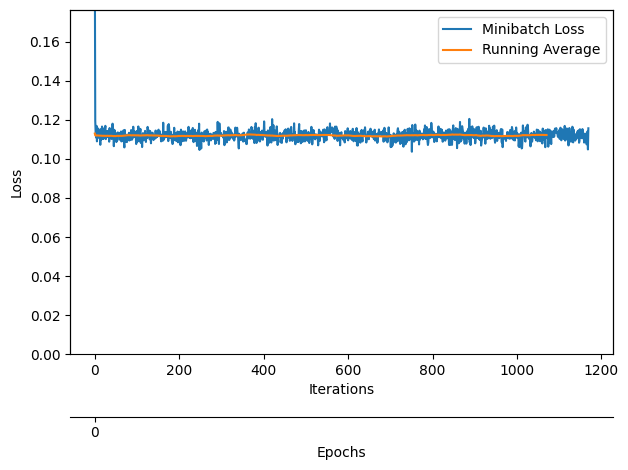

In [38]:
plot_training_loss(log_dict['train_loss_per_batch'], 5,3)
plt.show()

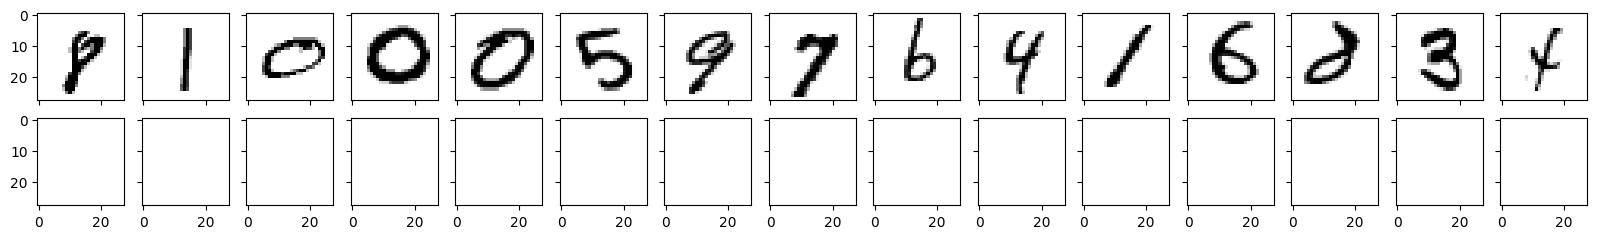

In [37]:
plot_generated_images(data_loader=train_loader, model=model, device=device)  

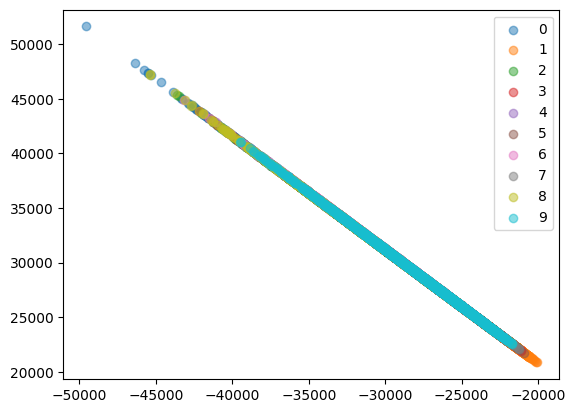

In [39]:
plot_latent_space_with_labels(
    num_classes=10,
    data_loader=train_loader,
    model=model, 
    device=device)

plt.legend()
plt.show()